In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("✅ All imports successful!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

✅ All imports successful!
TensorFlow version: 2.21.0
GPU available: []


In [10]:
PROCESSED_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\processed"
MODEL_PATH      = r"D:\Development\8th Sem Project\TomatoClassification\models"

IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 10
EPOCHS      = 20

os.makedirs(MODEL_PATH, exist_ok=True)

print(f"✅ Paths configured!")
print(f"📁 Dataset : {PROCESSED_PATH}")
print(f"💾 Models  : {MODEL_PATH}")
print(f"🖼️  Image size : {IMAGE_SIZE}")
print(f"📦 Batch size : {BATCH_SIZE}")
print(f"🔁 Epochs     : {EPOCHS}")

✅ Paths configured!
📁 Dataset : D:\Development\8th Sem Project\TomatoClassification\dataset\processed
💾 Models  : D:\Development\8th Sem Project\TomatoClassification\models
🖼️  Image size : (224, 224)
📦 Batch size : 32
🔁 Epochs     : 20


In [ ]:
# Training data — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation & Test — NO augmentation, only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training images
train_generator = train_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Load validation images
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Load test images
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Data loaded!")
print(f"🏋️  Training   : {train_generator.samples} images")
print(f"✔️  Validation : {val_generator.samples} images")
print(f"🧪 Test       : {test_generator.samples} images")
print(f"\n📋 Classes found: {list(train_generator.class_indices.keys())}")

Found 6527 images belonging to 10 classes.
Found 1399 images belonging to 10 classes.
Found 1399 images belonging to 10 classes.

✅ Data loaded!
🏋️  Training   : 6527 images
✔️  Validation : 1399 images
🧪 Test       : 1399 images

📋 Classes found: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
# Load MobileNetV2 pretrained on ImageNet, without its top layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model — don't retrain pretrained weights
base_model.trainable = False

# Add our custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Combine into final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built successfully!")
print(f"📊 Total layers      : {len(model.layers)}")
print(f"🔒 Trainable params  : {model.count_params():,}")
#model.summary()

✅ Model built successfully!
📊 Total layers      : 158
🔒 Trainable params  : 2,423,242


In [13]:
# Callbacks — smart controls during training
callbacks = [
    # Stop training if val_loss doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Save the best model automatically
    ModelCheckpoint(
        filepath=os.path.join(MODEL_PATH, 'best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Reduce learning rate if stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("🚀 Starting training...\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

print("\n✅ Training complete!")

🚀 Starting training...

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 944ms/step - accuracy: 0.4842 - loss: 1.5090
Epoch 1: val_accuracy improved from None to 0.76126, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5



Epoch 1: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.6171 - loss: 1.1214 - val_accuracy: 0.7613 - val_loss: 0.7193 - learning_rate: 0.0010
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.7665 - loss: 0.7014
Epoch 2: val_accuracy improved from 0.76126 to 0.81344, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5



Epoch 2: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.7706 - loss: 0.6742 - val_accuracy: 0.8134 - val_loss: 0.5523 - learning_rate: 0.0010
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.8059 - loss: 0.5553
Epoch 3: val_accuracy improved from 0.81344 to 0.84203, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5



Epoch 3: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 173s 849ms/step - accuracy: 0.8060 - loss: 0.5544 - val_accuracy: 0.8420 - val_loss: 0.5093 - learning_rate: 0.0010
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.8310 - loss: 0.5148
Epoch 4: val_accuracy improved from 0.84203 to 0.84703, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5



Epoch 4: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 164s 803ms/step - accuracy: 0.8362 - loss: 0.5016 - val_accuracy: 0.8470 - val_loss: 0.4598 - learning_rate: 0.0010
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.8489 - loss: 0.4513
Epoch 5: val_accuracy improved from 0.84703 to 0.86133, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5


...


Epoch 12: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 182s 892ms/step - accuracy: 0.9062 - loss: 0.2769 - val_accuracy: 0.8713 - val_loss: 0.3887 - learning_rate: 5.0000e-04
Epoch 13/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.9004 - loss: 0.2802
Epoch 13: val_accuracy did not improve from 0.87134
204/204 ━━━━━━━━━━━━━━━━━━━━ 194s 949ms/step - accuracy: 0.9013 - loss: 0.2775 - val_accuracy: 0.8556 - val_loss: 0.4036 - learning_rate: 5.0000e-04
Epoch 14/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9091 - loss: 0.2626
Epoch 14: val_accuracy did not improve from 0.87134
204/204 ━━━━━━━━━━━━━━━━━━━━ 184s 902ms/step - accuracy: 0.9090 - loss: 0.2636 - val_accuracy: 0.8713 - val_loss: 0.3826 - learning_rate: 5.0000e-04
Epoch 15/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.9199 - loss: 0.2439
Epoch 15: val_accuracy improved from 0.87134 to 0.87491, saving model to 


Epoch 15: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 168s 824ms/step - accuracy: 0.9191 - loss: 0.2439 - val_accuracy: 0.8749 - val_loss: 0.3920 - learning_rate: 5.0000e-04
Epoch 16/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.9079 - loss: 0.2556
Epoch 16: val_accuracy improved from 0.87491 to 0.87777, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5



Epoch 16: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 171s 838ms/step - accuracy: 0.9058 - loss: 0.2582 - val_accuracy: 0.8778 - val_loss: 0.3891 - learning_rate: 5.0000e-04
Epoch 17/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.9200 - loss: 0.2452
Epoch 17: val_accuracy improved from 0.87777 to 0.87991, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5



Epoch 17: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 167s 819ms/step - accuracy: 0.9159 - loss: 0.2521 - val_accuracy: 0.8799 - val_loss: 0.3788 - learning_rate: 5.0000e-04
Epoch 18/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.9104 - loss: 0.2536
Epoch 18: val_accuracy improved from 0.87991 to 0.88849, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5



Epoch 18: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 168s 823ms/step - accuracy: 0.9111 - loss: 0.2485 - val_accuracy: 0.8885 - val_loss: 0.3554 - learning_rate: 5.0000e-04
Epoch 19/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.9216 - loss: 0.2271
Epoch 19: val_accuracy did not improve from 0.88849
204/204 ━━━━━━━━━━━━━━━━━━━━ 165s 811ms/step - accuracy: 0.9180 - loss: 0.2385 - val_accuracy: 0.8828 - val_loss: 0.3754 - learning_rate: 5.0000e-04
Epoch 20/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9227 - loss: 0.2316
Epoch 20: val_accuracy did not improve from 0.88849
204/204 ━━━━━━━━━━━━━━━━━━━━ 167s 820ms/step - accuracy: 0.9222 - loss: 0.2326 - val_accuracy: 0.8813 - val_loss: 0.3593 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 18.

✅ Training complete!


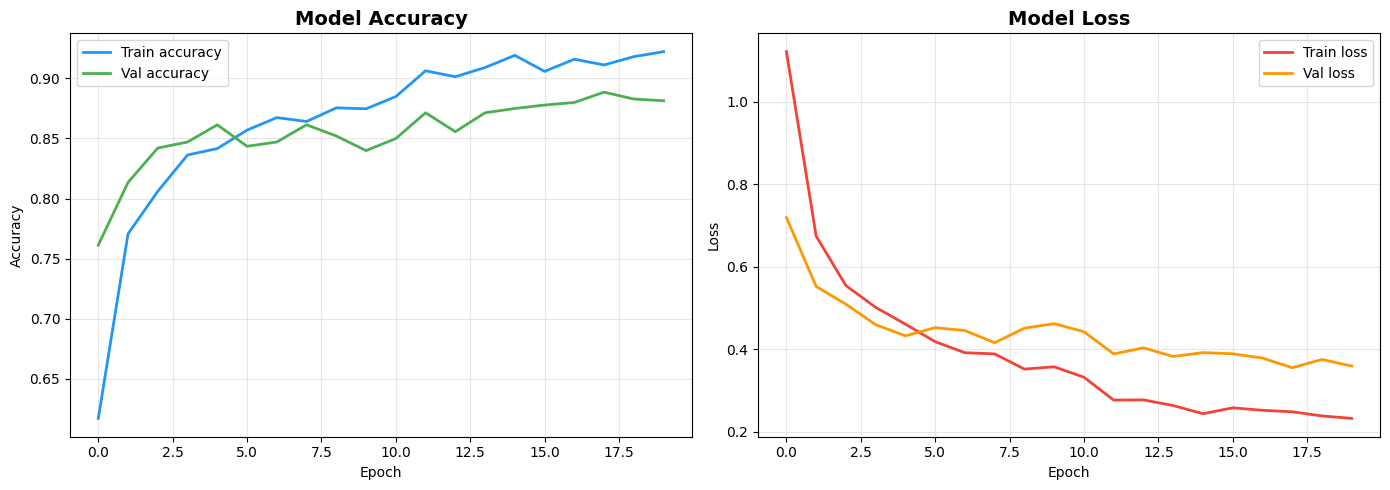


📊 Final Results:
   Best Train Accuracy : 92.22%
   Best Val Accuracy   : 88.85%
   Final Train Loss    : 0.2326
   Final Val Loss      : 0.3593


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],
             label='Train accuracy', color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Val accuracy', color='#4CAF50', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'],
             label='Train loss', color='#F44336', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Val loss', color='#FF9800', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Final Results:")
print(f"   Best Train Accuracy : {max(history.history['accuracy']):.2%}")
print(f"   Best Val Accuracy   : {max(history.history['val_accuracy']):.2%}")
print(f"   Final Train Loss    : {history.history['loss'][-1]:.4f}")
print(f"   Final Val Loss      : {history.history['val_loss'][-1]:.4f}")

In [15]:
# Save final model
final_model_path = os.path.join(MODEL_PATH, 'tomato_classifier_final.h5')
model.save(final_model_path)

print(f"✅ Final model saved!")
print(f"💾 Location : {final_model_path}")
print(f"\n📁 Models folder now contains:")
for f in os.listdir(MODEL_PATH):
    size = os.path.getsize(os.path.join(MODEL_PATH, f)) / (1024*1024)
    print(f"   {f} — {size:.1f} MB")

✅ Final model saved!
💾 Location : D:\Development\8th Sem Project\TomatoClassification\models\tomato_classifier_final.h5

📁 Models folder now contains:
   best_model.h5 — 11.0 MB
   tomato_classifier_final.h5 — 11.0 MB
